# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('/content/drive/MyDrive/Data/yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

In [3]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,month,hour,weekday,weekday_num,week,year,day
datetime,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,1,0,Saturday,5,52,2011,1
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,1,1,Saturday,5,52,2011,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,1,2,Saturday,5,52,2011,1
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,1,3,Saturday,5,52,2011,1
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,1,4,Saturday,5,52,2011,1


## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [4]:
monthly_rents = df['count'].resample('ME').mean()

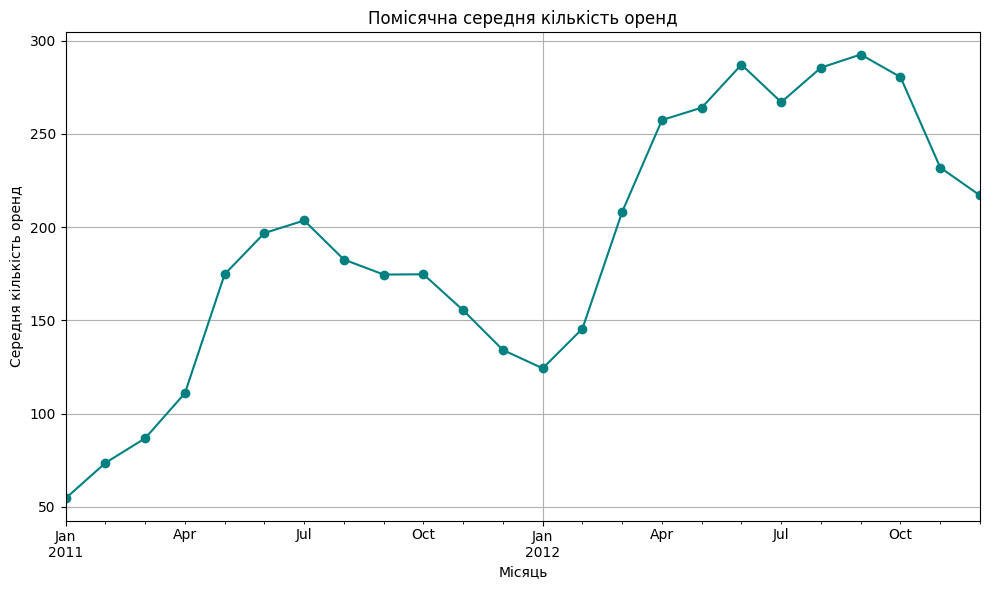

In [20]:
# viz with Pandas

monthly_rents.plot (
    figsize=(10, 6),
    xlabel='Місяць',
    ylabel='Середня кількість оренд',
    marker='o',
    color='teal',
    grid=True,
    title='Помісячна середня кількість оренд'
)

plt.tight_layout()


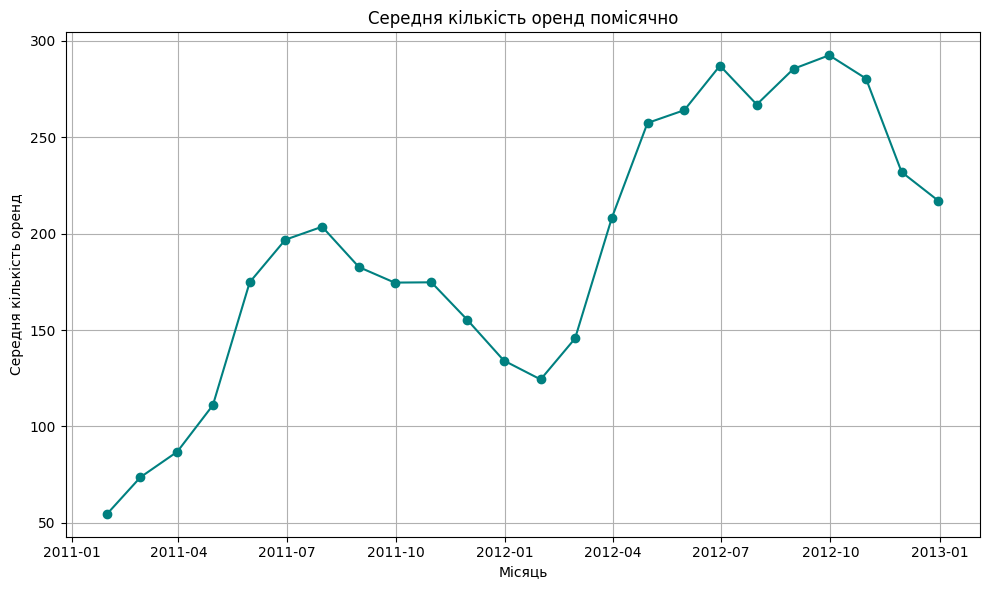

In [22]:
# viz with Matplotlib

plt.figure(figsize=(10, 6))
plt.plot(monthly_rents, marker='o', color='teal')
plt.title('Середня кількість оренд помісячно')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренд')
plt.tight_layout()
plt.grid(True)

У графіку побудований з Pandas лінія доходить до кінця фігури, що не дуже зручно як на мене, але більш зрозумілий формат підпису осі X.

В другому ж варіанті відображаються повні дати у форматі YYYY-MM, тому підписи займають більше місця. Але сітка робить графік більш читабельним.

Все ж таки варіант з Matplotlib дає більше можливостей для оформлення та виглядає більш професійно.

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень проодажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [7]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

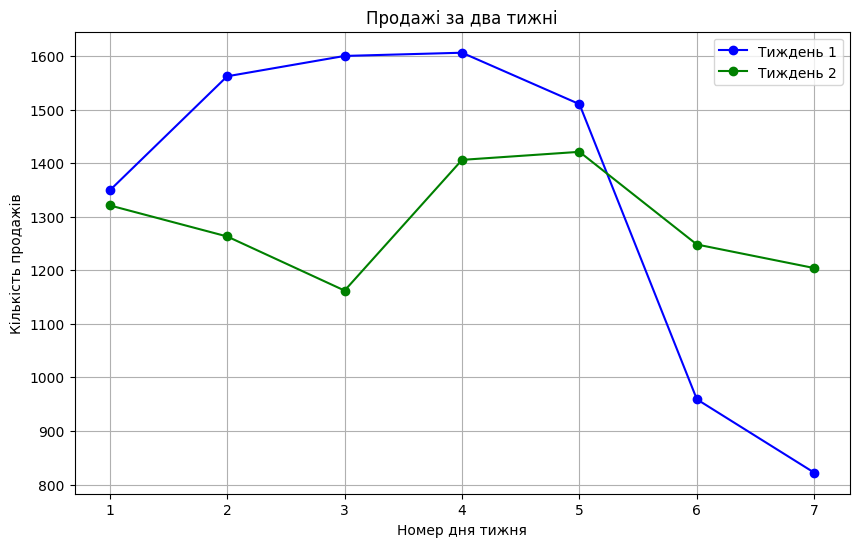

In [8]:
plt.figure(figsize=(10, 6))

plt.plot(days, sales_week1, marker='o', color='blue', label='Тиждень 1')
plt.plot(days, sales_week2, marker='o', color='green', label='Тиждень 2')

plt.title('Продажі за два тижні')
plt.xlabel('Номер дня тижня')
plt.ylabel('Кількість продажів')
plt.legend()
plt.grid(True)


1. Відповідно до візуалізації продажі за другий тиждень були більш стабільними.

2. За допомогою Numpy можна порахувати певні статистичні обсичлення

In [9]:
# Стандартне відхилення

std_week1 = np.std(sales_week1)
std_week2 = np.std(sales_week2)

print('Стандартне відхилення тиждень 1', std_week1)
print('Стандартне відхилення тиждень 2', std_week2)

Стандартне відхилення тиждень 1 299.99857142517004
Стандартне відхилення тиждень 2 90.9060964256355


In [10]:
# Дисперсія

var_week1 = np.var(sales_week1)
var_week2 = np.var(sales_week2)

print('Дсиперсія тиждень 1', var_week1)
print('Дсиперсія тиждень 2', var_week2)

Дсиперсія тиждень 1 89999.14285714286
Дсиперсія тиждень 2 8263.91836734694


Отримані значення стандартного відхилення та дисперсії підтверджують висновки візуалізації.

## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [73]:
# підготовка даних

# середня темпераура помісячно

temp_avg = df['temp'].resample('ME').mean()

# середня годинна кількість оренд за кварталами

quarter_avg = df.groupby(df.index.quarter)['count'].mean()

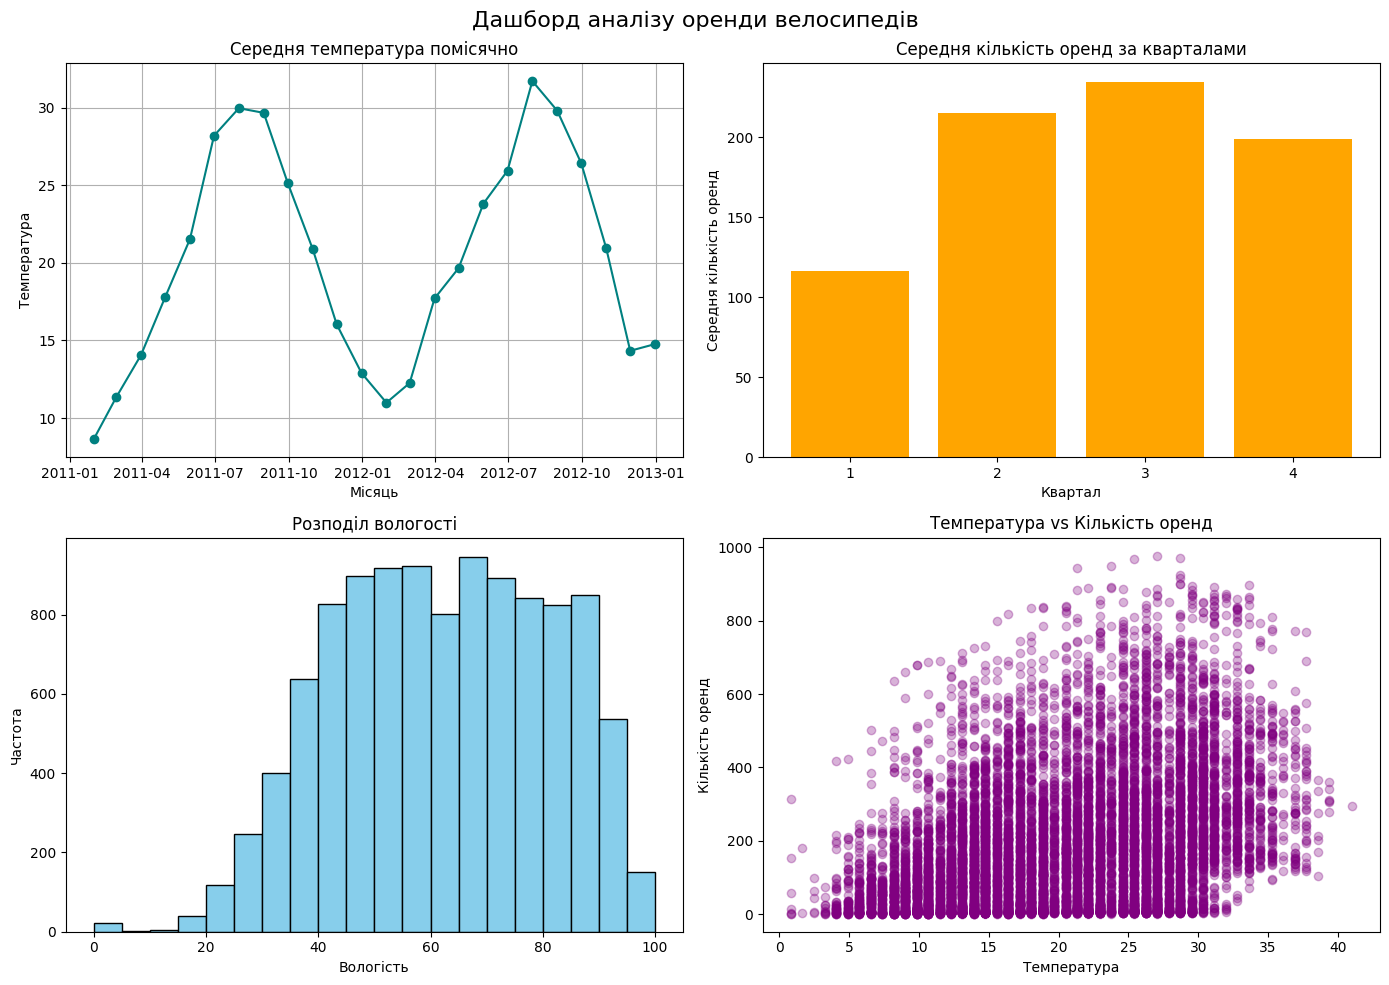

In [74]:
plt.figure(figsize=(14,10))

# лінійний графік температури
plt.subplot(2, 2, 1)
plt.plot(temp_avg, marker='o', color='teal')
plt.title('Середня температура помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура')
plt.grid(True)

# стовпчикова діаграма по кварталах
plt.subplot(2, 2, 2)
plt.bar(quarter_avg.index, quarter_avg.values, color='orange')
plt.title('Середня кількість оренд за кварталами')
plt.xlabel('Квартал')
plt.ylabel('Середня кількість оренд')

plt.xticks([1, 2, 3, 4])

# гістограма вологості
plt.subplot(2, 2, 3)
plt.hist(df['humidity'], bins=20, color='skyblue', edgecolor='black')
plt.title('Розподіл вологості')
plt.xlabel('Вологість')
plt.ylabel('Частота')

# scatter temp vs count
plt.subplot(2, 2, 4)
plt.scatter(df['temp'], df['count'], alpha=0.3, color='purple')
plt.title('Температура vs Кількість оренд')
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')

plt.suptitle('Дашборд аналізу оренди велосипедів', fontsize=16)

plt.tight_layout()


## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

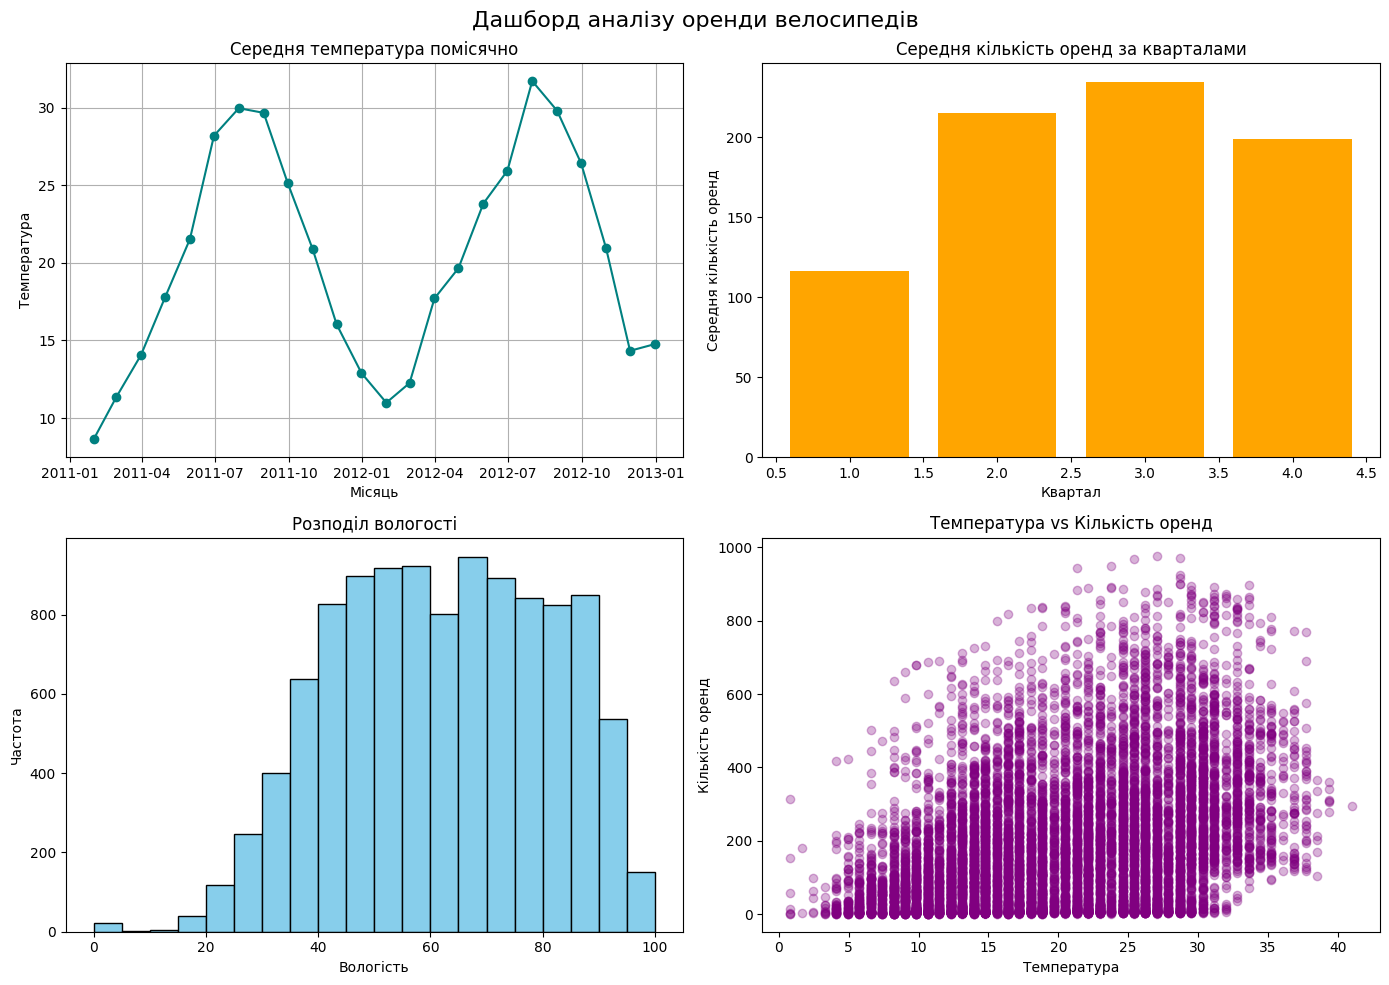

In [27]:
fig, ax = plt.subplots(2, 2, figsize=(14, 10))

# лінійний графік температури
ax[0, 0].plot(temp_avg, marker='o', color='teal')
ax[0, 0].set_title('Середня температура помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура')
ax[0, 0].grid(True)

# стовпчикова діаграма по кварталах
ax[0, 1].bar(quarter_avg.index, quarter_avg.values, color='orange')
ax[0, 1].set_title('Середня кількість оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_ylabel('Середня кількість оренд')

# гістограма вологості
ax[1, 0].hist(df['humidity'], bins=20, color='skyblue', edgecolor='black')
ax[1, 0].set_title('Розподіл вологості')
ax[1, 0].set_xlabel('Вологість')
ax[1, 0].set_ylabel('Частота')

# scatter temp vs count
ax[1, 1].scatter(df['temp'], df['count'], alpha=0.3, color='purple')
ax[1, 1].set_title('Температура vs Кількість оренд')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренд')

fig.suptitle('Дашборд аналізу оренди велосипедів', fontsize=16)

plt.tight_layout()

Коли ми використовуємо plt.subplot(), ми створюємо графіки по одному. Спочатку вибираємо місце для першого графіка, потім для другого і так далі. Це простий спосіб і більш сарий підхід.

Коли ми використовуємо plt.subplots(), ми одразу створюємо фігуру і отримуємо змінну ax, що преставляє масив. Це більше зручний і правильний підхід, якщо графіків багато. Також він дає більше можливостей стосовно підписів, стилів і тд

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [29]:
import matplotlib.dates as mdates

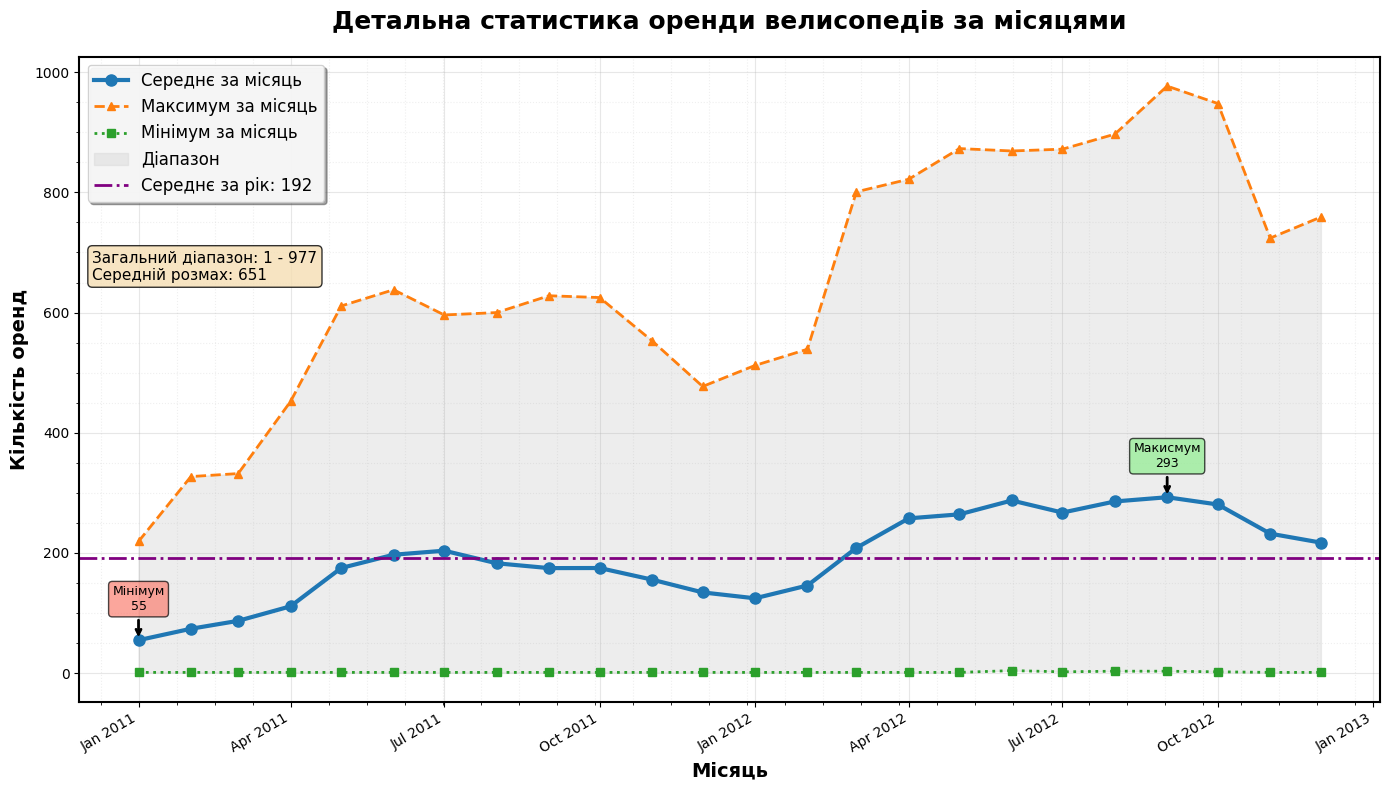

In [72]:
monthly_mean = df['count'].resample('MS').mean()
monthly_min  = df['count'].resample('MS').min()
monthly_max  = df['count'].resample('MS').max()

overall_mean = df['count'].mean()

# Індекси екстремумів середнього
max_idx = monthly_max.idxmax()
max_val = monthly_max.max()

min_idx = monthly_min.idxmin()
min_val = monthly_min.min()

# Побудова графіка
fig, ax = plt.subplots(figsize=(14, 8))

# Три лінії з різними стилями
ax.plot(monthly_mean.index, monthly_mean, linestyle='-', marker='o',
        linewidth=3, markersize=8, label='Середнє за місяць')

ax.plot(monthly_max.index, monthly_max, linestyle='--', marker='^',
        linewidth=2, markersize=6, label='Максимум за місяць')

ax.plot(monthly_min.index, monthly_min, linestyle=':', marker='s',
        linewidth=2, markersize=6, label='Мінімум за місяць')

# Заливка між max та min
ax.fill_between(monthly_mean.index, monthly_min, monthly_max,
                color='lightgray',alpha=0.4, label='Діапазон')

# Горизонтальна лінія середнього за весь період
ax.axhline(overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# Анотації екстремумів
ax.annotate(f'Макисмум\n{monthly_mean.max():.0f}',
            xy=(max_idx, monthly_mean.max()), xytext=(max_idx, monthly_mean.max() + 50),
            arrowprops=dict(arrowstyle='->', lw=2),
            fontsize=9, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='lightgreen', alpha=0.7))

ax.annotate(f'Мінімум\n{monthly_mean.min():.0f}',
            xy=(min_idx, monthly_mean.min()), xytext=(min_idx, monthly_mean.min() + 50),
            arrowprops=dict(arrowstyle='->', lw=2),
            fontsize=9, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='salmon', alpha=0.7))

# Форматування осей
ax.set_title('Детальна статистика оренди велисопедів за місяцями', fontsize=18, fontweight='bold', pad=20)
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренд', fontsize=14, fontweight='bold')

# Форматування дат
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

fig.autofmt_xdate(rotation=30, ha='right')

# Додаємо сітку з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Легенда
ax.legend(loc='upper left', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Додаємо текст з додатковою статистикою
textstr = f'Загальний діапазон: {monthly_min.min():.0f} - {monthly_max.max():.0f}\n'
textstr += f'Середній розмах: {(monthly_max - monthly_min).mean():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)

ax.text(0.01, 0.70, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()